#### What is machine learning, and what is our goal here? In your own words, define the goal of machine learning (briefly).  What kind of prediction could we make using this dataset? What variable seems like a good target? ####

Machine learning uses data to make predictions. The goal of ML is to quickly make predicitions without a person getting involved to do it. For example, with the spotify data set, we can predict how danceable a song is with other variables.

In [213]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("spotifytop2019.csv")

In [214]:
import seaborn as sns
import numpy as np

In [215]:
print(df.head())

                      id                                           name  \
0  6v3KW9xbzN5yKLt9YKDYA                                       Señorita   
1  2Fxmhks0bxGSBdJ92vM42                                        bad guy   
2  0RiRZpuVRbi7oqRdSMwhQ  Sunflower - Spider-Man: Into the Spider-Verse   
3  6ocbgoVGwYJhOv1GgI9Ns                                        7 rings   
4  2YpeDb67231RjR0MgVLzs                          Old Town Road - Remix   

         artists  danceability  energy  key  loudness  mode  speechiness  \
0   Shawn Mendes         0.759   0.548  9.0    -6.049   0.0       0.0290   
1  Billie Eilish         0.701   0.425  7.0   -10.965   1.0       0.3750   
2    Post Malone         0.755   0.522  2.0    -4.368   1.0       0.0575   
3  Ariana Grande         0.778   0.317  1.0   -10.732   0.0       0.3340   
4      Lil Nas X         0.878   0.619  6.0    -5.560   1.0       0.1020   

   acousticness  instrumentalness  liveness  valence    tempo  duration_ms  \
0        0.039

In [216]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50 non-null     str    
 1   name              50 non-null     str    
 2   artists           50 non-null     str    
 3   danceability      50 non-null     float64
 4   energy            50 non-null     float64
 5   key               50 non-null     float64
 6   loudness          50 non-null     float64
 7   mode              50 non-null     float64
 8   speechiness       50 non-null     float64
 9   acousticness      50 non-null     float64
 10  instrumentalness  50 non-null     float64
 11  liveness          50 non-null     float64
 12  valence           50 non-null     float64
 13  tempo             50 non-null     float64
 14  duration_ms       50 non-null     float64
 15  time_signature    50 non-null     float64
dtypes: float64(13), str(3)
memory usage: 6.4 KB


In [217]:
df=df.drop(columns=['id','name','artists'])

In [218]:
df.describe()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
count,50.000000,50.00000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.0
mean,0.719400,0.60462,5.280000,-6.229000,0.580000,0.127582,0.299381,0.006039,0.132792,0.490460,120.425700,201691.620000,4.0
std,0.130358,0.16975,3.295266,2.725249,0.498569,0.103008,0.255321,0.029065,0.074088,0.219144,28.740856,44213.177325,0.0
min,0.351000,0.11100,0.000000,-14.505000,0.000000,0.029000,0.005130,0.000000,0.057400,0.120000,71.105000,113000.000000,4.0
25%,0.657500,0.52000,2.000000,-7.056000,0.000000,0.053675,0.095900,0.000000,0.088425,0.330500,97.316000,175840.000000,4.0
50%,0.743000,0.62400,5.000000,-5.759000,1.000000,0.081350,0.244000,0.000000,0.106000,0.495000,116.125500,193657.500000,4.0
75%,0.814500,0.73225,8.000000,-4.295250,1.000000,0.199000,0.449250,0.000003,0.141250,0.637000,137.478750,215372.250000,4.0
max,0.907000,0.90400,11.000000,-2.652000,1.000000,0.375000,0.978000,0.162000,0.437000,0.952000,179.974000,354320.000000,4.0


array([[<Axes: title={'center': 'danceability'}>,
        <Axes: title={'center': 'energy'}>,
        <Axes: title={'center': 'key'}>,
        <Axes: title={'center': 'loudness'}>],
       [<Axes: title={'center': 'mode'}>,
        <Axes: title={'center': 'speechiness'}>,
        <Axes: title={'center': 'acousticness'}>,
        <Axes: title={'center': 'instrumentalness'}>],
       [<Axes: title={'center': 'liveness'}>,
        <Axes: title={'center': 'valence'}>,
        <Axes: title={'center': 'tempo'}>,
        <Axes: title={'center': 'duration_ms'}>],
       [<Axes: title={'center': 'time_signature'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

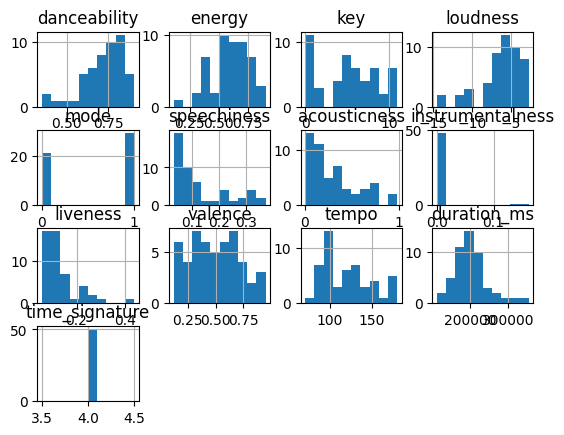

In [219]:
df.hist(bins=10)

In [220]:
top_10_danceability = df.nlargest(n=10, columns=['danceability'])
print(top_10_danceability)

    danceability  energy   key  loudness  mode  speechiness  acousticness  \
18         0.907   0.530   1.0    -6.112   1.0       0.1270       0.05780   
17         0.905   0.389   8.0   -14.505   1.0       0.3320       0.74000   
19         0.901   0.400   0.0    -8.575   1.0       0.1260       0.05100   
31         0.889   0.496   4.0    -6.365   0.0       0.0905       0.25900   
4          0.878   0.619   6.0    -5.560   1.0       0.1020       0.05330   
14         0.842   0.734   1.0    -5.065   0.0       0.0588       0.04270   
27         0.842   0.801   8.0    -4.167   0.0       0.2280       0.15700   
24         0.837   0.364   8.0   -11.713   1.0       0.2760       0.14900   
30         0.834   0.730   8.0    -3.714   1.0       0.2220       0.00513   
6          0.829   0.539  11.0    -7.359   0.0       0.2080       0.13600   

    instrumentalness  liveness  valence    tempo  duration_ms  time_signature  
18          0.000002    0.1010    0.507  135.998     113000.0           

In [221]:
bottom_5_danceability = df.nsmallest(n=5, columns=['danceability'])
print(bottom_5_danceability)

    danceability  energy  key  loudness  mode  speechiness  acousticness  \
29         0.351   0.296  4.0   -10.109   0.0       0.0333         0.934   
20         0.367   0.111  4.0   -14.084   1.0       0.0972         0.978   
37         0.414   0.404  0.0    -9.928   0.0       0.0499         0.271   
7          0.501   0.405  1.0    -5.679   1.0       0.0319         0.751   
9          0.572   0.385  7.0    -6.362   1.0       0.0308         0.371   

    instrumentalness  liveness  valence    tempo  duration_ms  time_signature  
29           0.00000    0.0950    0.120  115.284     200186.0             4.0  
20           0.00004    0.0897    0.198   82.642     196077.0             4.0  
37           0.00000    0.3000    0.224   71.105     354320.0             4.0  
7            0.00000    0.1050    0.446  109.891     182161.0             4.0  
9            0.00000    0.2310    0.323   95.799     215733.0             4.0  


In [222]:
correlation = df.corr()
dance_correlation = correlation["danceability"].sort_values()
print(dance_correlation)

acousticness       -0.465118
duration_ms        -0.132798
liveness           -0.088595
mode                0.007662
tempo               0.149066
instrumentalness    0.153419
key                 0.165208
loudness            0.178688
speechiness         0.227283
energy              0.273068
valence             0.391774
danceability        1.000000
time_signature           NaN
Name: danceability, dtype: float64


Text(0, 0.5, 'predicted y')

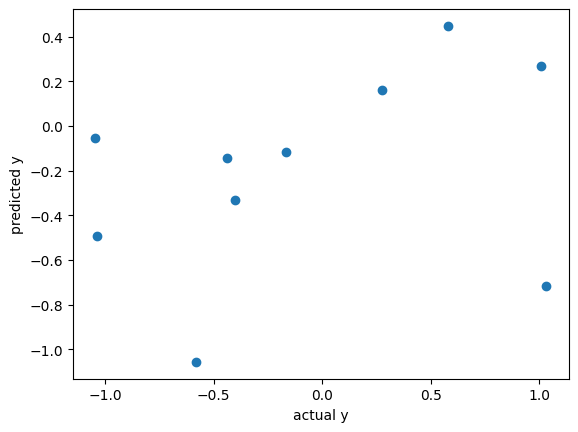

In [223]:
from sklearn.linear_model import LinearRegression
model = LinearRegression(fit_intercept=True)

from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
df[['danceability', 'energy', 'loudness', 'tempo']] = scaler.fit_transform(df[['danceability', 'energy', 'loudness', 'tempo']])

from sklearn.model_selection import train_test_split
X = df[["speechiness", "acousticness", "liveness"]]
y = df["danceability"] 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rng = np.random.RandomState(42)
model = LinearRegression(fit_intercept=True)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
plt.scatter(y_test,y_pred);
plt.xlabel("actual y")
plt.ylabel("predicted y")

In [224]:
df.head()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,0.101911,-0.358068,9.0,-0.105044,0.0,0.0290,0.0392,0.00,0.0828,0.749,0.020952,190800.0,4.0
1,-0.267516,-0.937574,7.0,-1.885719,1.0,0.3750,0.3280,0.13,0.1000,0.562,0.473137,194088.0,4.0
2,0.076433,-0.480565,2.0,0.503849,1.0,0.0575,0.5330,0.00,0.0685,0.925,-0.651487,157560.0,4.0
3,0.222930,-1.446408,1.0,-1.801322,0.0,0.3340,0.5920,0.00,0.0881,0.327,0.595639,178627.0,4.0
4,0.859873,-0.023557,6.0,0.072082,1.0,0.1020,0.0533,0.00,0.1130,0.639,0.495870,157067.0,4.0


In [225]:
model.coef_ #represents the slope

array([ 1.12038425, -1.75691464, -0.10790961])

In [226]:
model.intercept_ #represents interecpt of the simple linear fit to the data

np.float64(0.22199665403726276)

In [227]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(r2)
print(mse)

0.014491475937647658
0.5237664548898804


#### If the scatterplot was accurate, I would predict that the pattern would follow y=x. ####

Text(0, 0.5, 'predicted y')

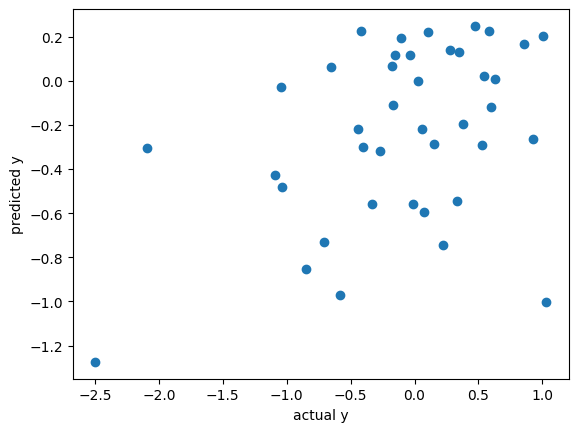

In [228]:
X = df[["speechiness", "acousticness", "liveness"]]
y = df["danceability"] 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=42)

rng = np.random.RandomState(42)
model2 = LinearRegression(fit_intercept=True)
model2.fit(X_train,y_train)
y_pred = model2.predict(X_test)
plt.scatter(y_test,y_pred);
plt.xlabel("actual y")
plt.ylabel("predicted y")

In [229]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(r2)
print(mse)

0.12236415328721628
0.49380980344028114


### Accuracy of smaller data set: ###
The accuracy has decreased with a smaller training set.

Text(0, 0.5, 'predicted y')

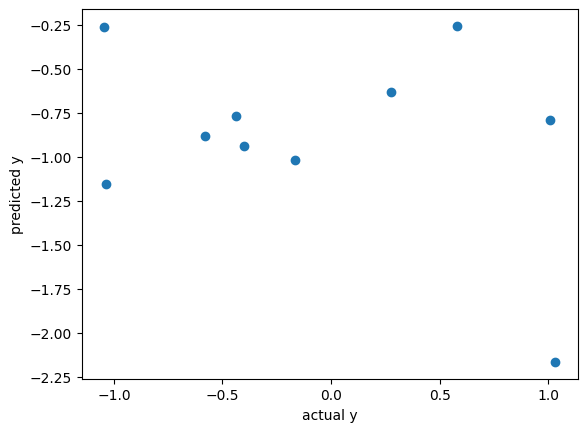

In [231]:
X = df[["speechiness", "acousticness", "liveness", "energy", 
        "key", "loudness", "mode", "instrumentalness", 
        "valence", "tempo", "duration_ms"]]
y = df["danceability"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rng = np.random.RandomState(42)
model3 = LinearRegression(fit_intercept=True)
model3.fit(X_train,y_train)
y_pred = model3.predict(X_test)
plt.scatter(y_test,y_pred);
plt.xlabel("actual y")
plt.ylabel("predicted y")

In [232]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(r2)
print(mse)

-2.162962358569395
1.6810139547744913


<Axes: >

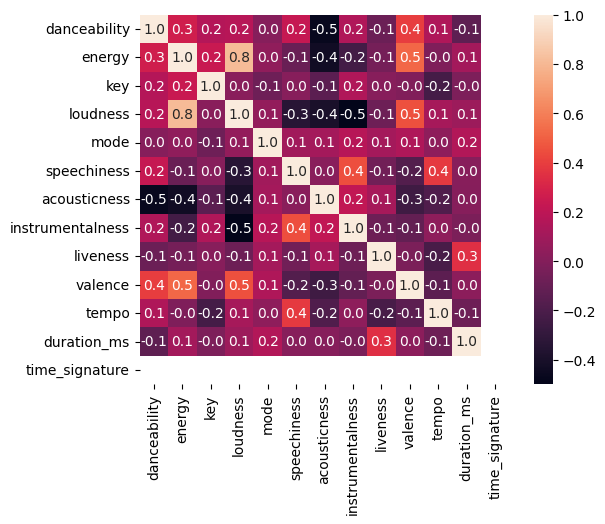

In [233]:
sns.heatmap(correlation,annot=True,fmt=".1f",square=True)

From the heatmap, we can see that valence is the most positively correlated with danceability. On the other hand, acousticness has the strongest negative correlation (and overall the strongest correlation out of all features).

After going back and interpreting my R^2 and MSE values, model 1 and model 2 came out to be pretty similar in how good they were. Model 2's accuracy was slightly lower. Model 3 was terrible in all aspects.

### How to make a good model:
Good models use features that are well correlated with the target predict variable (one way to do this is with lasso). Normalizing data also helps with some data sets.